## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'        : 110,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.titlepad'     : 10,
})

INR = lambda x: f'₹{x/1e6:.1f}M'
print('Ready.')

Ready.


## 1. Database Connection

In [2]:
DB_USER     = 'root'
DB_PASSWORD = '12345'   # <-- change this
DB_NAME     = 'retail_rolap'
DB_HOST     = '127.0.0.1'
DB_PORT     = 3306

engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    pool_pre_ping=True
)

with engine.connect() as c:
    print(f'Connected → {DB_NAME}')

Connected → retail_rolap


## 2. Load Tables

In [3]:
def load(table, limit=None):
    q = f'SELECT * FROM {table}' + (f' LIMIT {limit}' if limit else '')
    df = pd.read_sql(q, engine)
    print(f'{table:35s} → {df.shape[0]:>8,} rows × {df.shape[1]} cols')
    return df

dim_date        = load('dim_date')
dim_product     = load('dim_product')
dim_store       = load('dim_store')
dim_customer    = load('dim_customer')
dim_supplier    = load('dim_supplier')
fact_sales      = load('fact_sales')

# Aggregate tables
agg_daily_store     = load('agg_daily_store_sales')
agg_monthly_cat     = load('agg_monthly_category_sales')
agg_monthly_store   = load('agg_monthly_store_performance')
agg_clv             = load('agg_customer_lifetime')

dim_date                            →    2,557 rows × 19 cols
dim_product                         →    2,000 rows × 11 cols
dim_store                           →      500 rows × 10 cols
dim_customer                        →   20,000 rows × 11 cols
dim_supplier                        →      300 rows × 9 cols
fact_sales                          →   50,000 rows × 17 cols
agg_daily_store_sales               →   46,727 rows × 8 cols
agg_monthly_category_sales          →      192 rows × 8 cols
agg_monthly_store_performance       →   11,788 rows × 8 cols
agg_customer_lifetime               →   18,371 rows × 9 cols


## 3. Data Preparation & Joins

In [4]:
# dim_date already has all time fields — merge into fact_sales
fact_sales = fact_sales.merge(
    dim_date[['date_id','full_date','year_val','month_val','month_name',
              'month_short','quarter_val','quarter_label',
              'weekday_name','is_weekend','fiscal_year','fiscal_month']],
    on='date_id', how='left'
)

fact_sales['full_date'] = pd.to_datetime(fact_sales['full_date'])
fact_sales['period']    = fact_sales['year_val'].astype(str) + '-' + fact_sales['month_val'].astype(str).str.zfill(2)

# Master sales — fact + all dims
sales = (fact_sales
    .merge(dim_product[['product_key','product_name','category','sub_category',
                         'brand','mrp','cost_price','gross_margin_pct',
                         'is_perishable','veg_nonveg']],
           on='product_key', how='left')
    .merge(dim_store[['store_key','store_name','city','state',
                       'city_tier','store_type','store_size_sqft']],
           on='store_key', how='left')
    .merge(dim_customer[['customer_key','customer_name','gender','age_group',
                          'city_tier','loyalty_member','customer_segment']],
           on='customer_key', how='left', suffixes=('_store','_cust'))
)

print(f'Master sales shape: {sales.shape}')
sales.head(3)

Master sales shape: (50000, 50)


,sale_key,transaction_id,date_id,product_key,store_key,customer_key,supplier_key,quantity,unit_price,discount_amount,sale_amount,cost_amount,profit,margin_pct,payment_mode,is_return,created_at,full_date,year_val,month_val,month_name,month_short,quarter_val,quarter_label,weekday_name,is_weekend,fiscal_year,fiscal_month,period,product_name,category,sub_category,brand,mrp,cost_price,gross_margin_pct,is_perishable,veg_nonveg,store_name,city,state,city_tier_store,store_type,store_size_sqft,customer_name,gender,age_group,city_tier_cust,loyalty_member,customer_segment
0,1,TXN00000004,20250923,1394,233,10470,NaN,5,75.00,6.70,341.50,253.10,88.40,25.89,Cash,0,2026-06-09 13:39:37,2025-09-23,2025,9,September,Sep,3,Q3,Tuesday,0,2025,6,2025-09,All Out Mosquito Liquid refill,Home Care,Repellents,All Out,75.00,50.62,32.51,0,,MegaMart Kolkata - Park-60,Kolkata,West Bengal,1,Express,2645,Pari Roy,Female,26-35,1,1,Regular
1,2,TXN00000007,20250814,1817,176,4251,NaN,5,110.00,9.77,501.15,482.75,18.40,3.67,Cash,0,2026-06-09 13:39:37,2025-08-14,2025,8,August,Aug,3,Q3,Thursday,0,2025,5,2025-08,Tropicana Mixed Fruit Juice 200ml,Beverages,Juices,Tropicana,110.00,96.55,12.23,0,Veg,FreshKart Ludhiana - Square-40,Ludhiana,Punjab,2,Supermarket,28313,Sai Reddy,Male,36-45,2,0,Regular
2,3,TXN00000010,20251023,285,4,13499,285.00,5,105.00,20.87,420.65,349.20,71.45,16.99,Cash,0,2026-06-09 13:39:37,2025-10-23,2025,10,October,Oct,4,Q4,Thursday,0,2025,7,2025-10,Farm Fresh Potato 2kg,Fruits & Vegetables,Fresh Vegetables,Farm Fresh,105.00,69.84,33.49,1,Veg,ValueStore Ludhiana - Square-32,Ludhiana,Punjab,2,Wholesale,40746,Saanvi Jain,Female,26-35,2,0,Occasional


---
# SECTION A — Revenue & Sales Trends

### Visual 1 — Monthly Revenue Trend

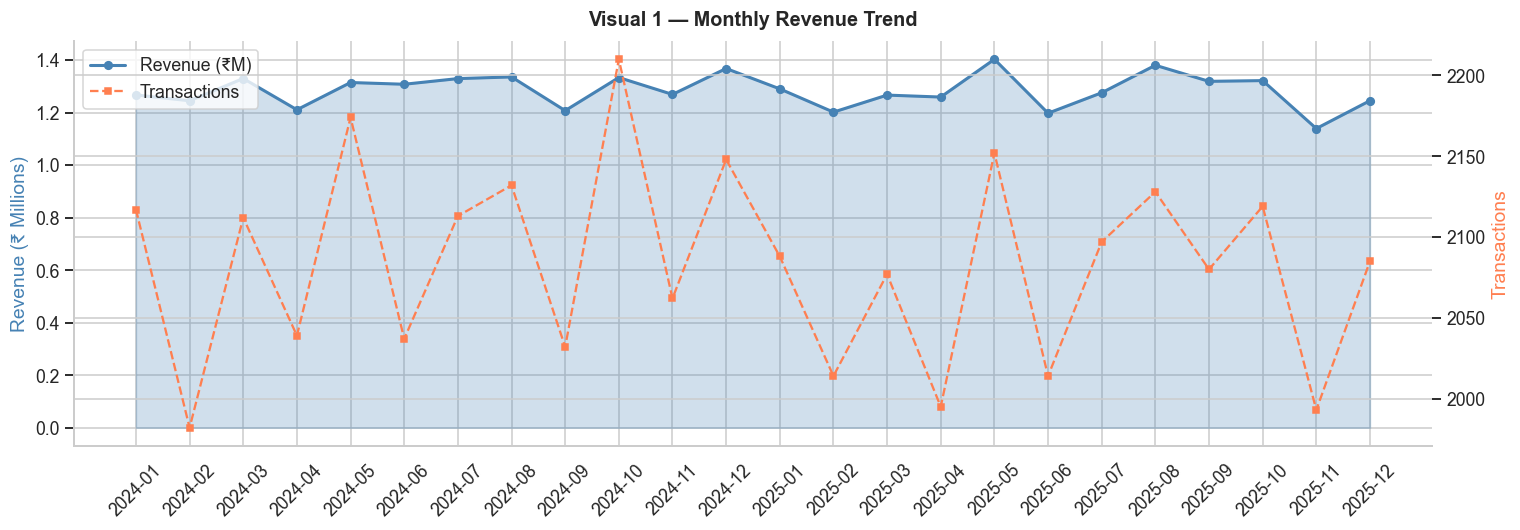


INSIGHT:
  Peak revenue month : 2025-05 — ₹1.4M
  Total revenue      : ₹30.8M across 24 months
  Avg monthly revenue: ₹1.3M



In [5]:
monthly = (sales.groupby('period')
           .agg(revenue=('sale_amount','sum'),
                orders=('transaction_id','nunique'),
                units=('quantity','sum'))
           .reset_index().sort_values('period'))

fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()

ax1.fill_between(monthly['period'], monthly['revenue']/1e6,
                 alpha=0.25, color='steelblue')
ax1.plot(monthly['period'], monthly['revenue']/1e6,
         marker='o', ms=5, color='steelblue', lw=2, label='Revenue (₹M)')
ax2.plot(monthly['period'], monthly['orders'],
         marker='s', ms=4, color='coral', lw=1.5, ls='--', label='Transactions')

ax1.set_title('Visual 1 — Monthly Revenue Trend')
ax1.set_ylabel('Revenue (₹ Millions)', color='steelblue')
ax2.set_ylabel('Transactions', color='coral')
ax1.tick_params(axis='x', rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()

peak = monthly.loc[monthly['revenue'].idxmax()]
print(f"""
INSIGHT:
  Peak revenue month : {peak['period']} — ₹{peak['revenue']/1e6:.1f}M
  Total revenue      : ₹{monthly['revenue'].sum()/1e6:.1f}M across {len(monthly)} months
  Avg monthly revenue: ₹{monthly['revenue'].mean()/1e6:.1f}M
""")

### Visual 2 — Year-over-Year Quarterly Revenue

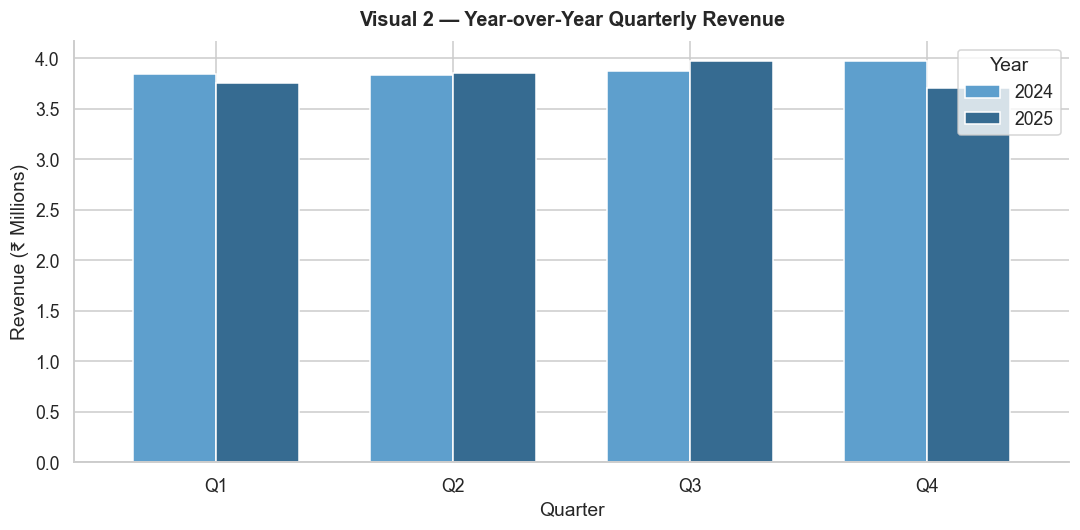


INSIGHT:
  Best quarter on average: Q3
  YoY comparison reveals growth trajectory per quarter.



In [6]:
yoy = (sales.groupby(['year_val','quarter_val'])['sale_amount']
       .sum().reset_index())
yoy_pivot = yoy.pivot(index='quarter_val', columns='year_val', values='sale_amount') / 1e6

ax = yoy_pivot.plot(kind='bar', figsize=(10,5), width=0.7,
                    color=sns.color_palette('Blues_d', len(yoy_pivot.columns)))
ax.set_title('Visual 2 — Year-over-Year Quarterly Revenue')
ax.set_xlabel('Quarter')
ax.set_ylabel('Revenue (₹ Millions)')
ax.set_xticklabels([f'Q{q}' for q in yoy_pivot.index], rotation=0)
ax.legend(title='Year')
plt.tight_layout()
plt.show()

best_q = yoy.groupby('quarter_val')['sale_amount'].mean().idxmax()
print(f"""
INSIGHT:
  Best quarter on average: Q{best_q}
  YoY comparison reveals growth trajectory per quarter.
""")

### Visual 3 — Day-of-Week Revenue Heatmap

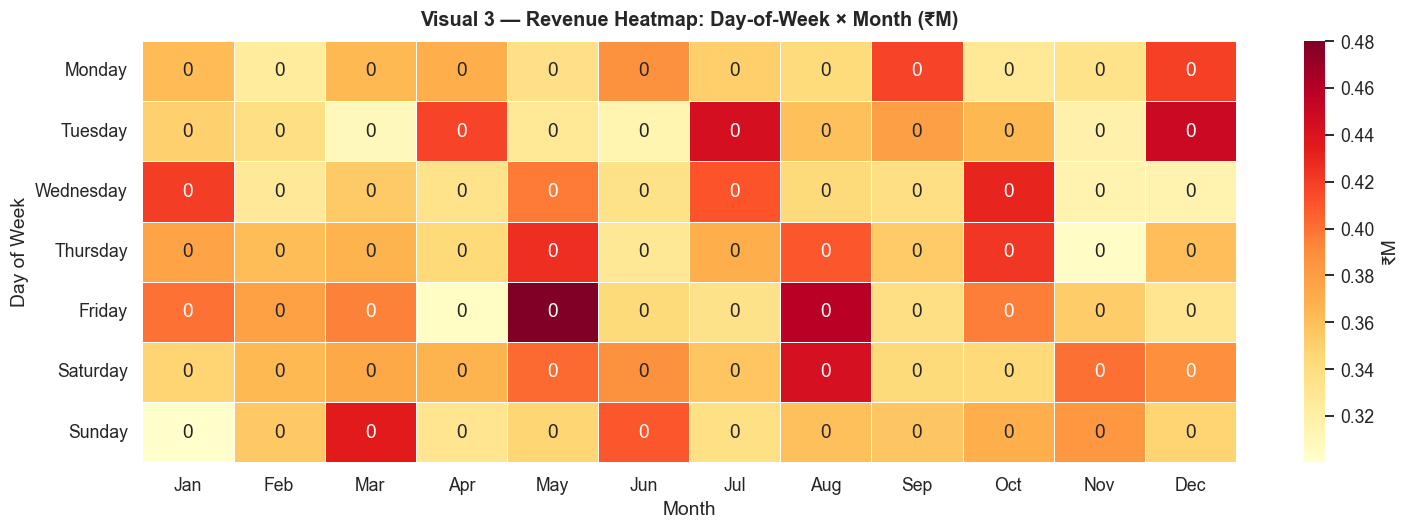


INSIGHT:
  Highest revenue day: Saturday
  Weekend vs weekday revenue pattern clearly visible.



In [7]:
dow_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

dow_month = (sales.groupby(['weekday_name','month_short'])['sale_amount']
             .sum().reset_index())
dow_pivot = dow_month.pivot(index='weekday_name', columns='month_short',
                            values='sale_amount') / 1e6
dow_pivot = dow_pivot.reindex(index=dow_order,
                               columns=[m for m in month_order if m in dow_pivot.columns])

fig, ax = plt.subplots(figsize=(14,5))
sns.heatmap(dow_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label':'₹M'})
ax.set_title('Visual 3 — Revenue Heatmap: Day-of-Week × Month (₹M)')
ax.set_xlabel('Month')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

best_dow = sales.groupby('weekday_name')['sale_amount'].sum().idxmax()
print(f"""
INSIGHT:
  Highest revenue day: {best_dow}
  Weekend vs weekday revenue pattern clearly visible.
""")

---
# SECTION B — Product & Category Analysis

### Visual 4 — Top 15 Categories by Revenue

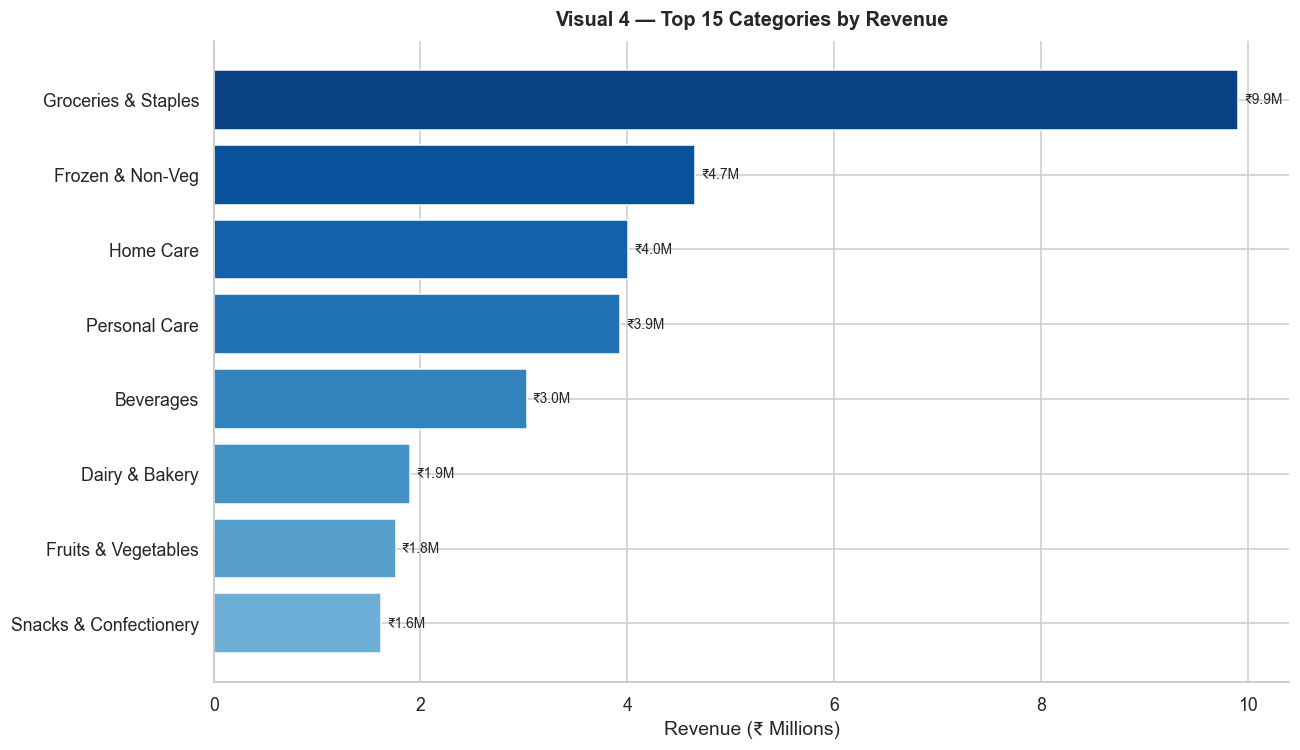


INSIGHT:
  Top 3 revenue categories: Groceries & Staples, Frozen & Non-Veg, Home Care
  Pareto principle — top categories likely drive 40-50% of revenue.



In [8]:
cat_rev = (sales.groupby('category')
           .agg(revenue=('sale_amount','sum'),
                units=('quantity','sum'),
                profit=('profit','sum'),
                margin_pct=('margin_pct','mean'))
           .sort_values('revenue', ascending=False)
           .head(15).reset_index())

fig, ax = plt.subplots(figsize=(12,7))
colors = sns.color_palette('Blues_r', 15)
bars = ax.barh(cat_rev['category'], cat_rev['revenue']/1e6, color=colors)
ax.bar_label(bars, fmt='₹%.1fM', padding=4, fontsize=9)
ax.set_title('Visual 4 — Top 15 Categories by Revenue')
ax.set_xlabel('Revenue (₹ Millions)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top3 = cat_rev.head(3)['category'].tolist()
print(f"""
INSIGHT:
  Top 3 revenue categories: {', '.join(top3)}
  Pareto principle — top categories likely drive 40-50% of revenue.
""")

### Visual 5 — Category Revenue vs Gross Margin % (Bubble Chart)

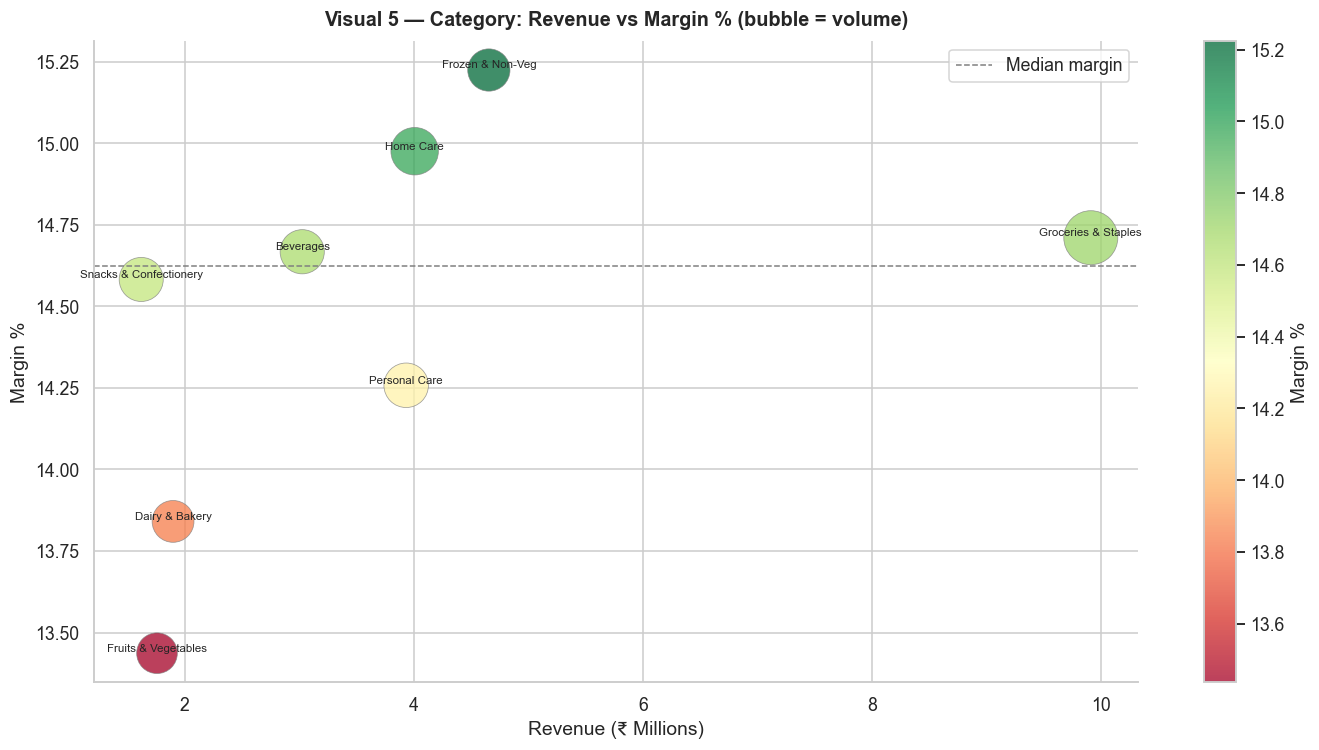


INSIGHT:
  Top-right = high revenue AND high margin — star categories.
  Bottom-right = high revenue, low margin — volume play, watch profitability.
  Top-left = high margin, low revenue — growth opportunity.



In [9]:
cat_bubble = (sales.groupby('category')
              .agg(revenue=('sale_amount','sum'),
                   margin_pct=('margin_pct','mean'),
                   units=('quantity','sum'))
              .reset_index())

fig, ax = plt.subplots(figsize=(13,7))
scatter = ax.scatter(
    cat_bubble['revenue']/1e6,
    cat_bubble['margin_pct'],
    s=cat_bubble['units']/cat_bubble['units'].max()*1200 + 50,
    c=cat_bubble['margin_pct'],
    cmap='RdYlGn', alpha=0.75, edgecolors='grey', lw=0.5
)
for _, row in cat_bubble.iterrows():
    ax.annotate(row['category'], (row['revenue']/1e6, row['margin_pct']),
                fontsize=7.5, ha='center', va='bottom')
plt.colorbar(scatter, ax=ax, label='Margin %')
ax.axhline(cat_bubble['margin_pct'].median(), color='gray', ls='--', lw=1, label='Median margin')
ax.set_title('Visual 5 — Category: Revenue vs Margin % (bubble = volume)')
ax.set_xlabel('Revenue (₹ Millions)')
ax.set_ylabel('Margin %')
ax.legend()
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  Top-right = high revenue AND high margin — star categories.
  Bottom-right = high revenue, low margin — volume play, watch profitability.
  Top-left = high margin, low revenue — growth opportunity.
""")

### Visual 6 — Top 10 Brands by Revenue

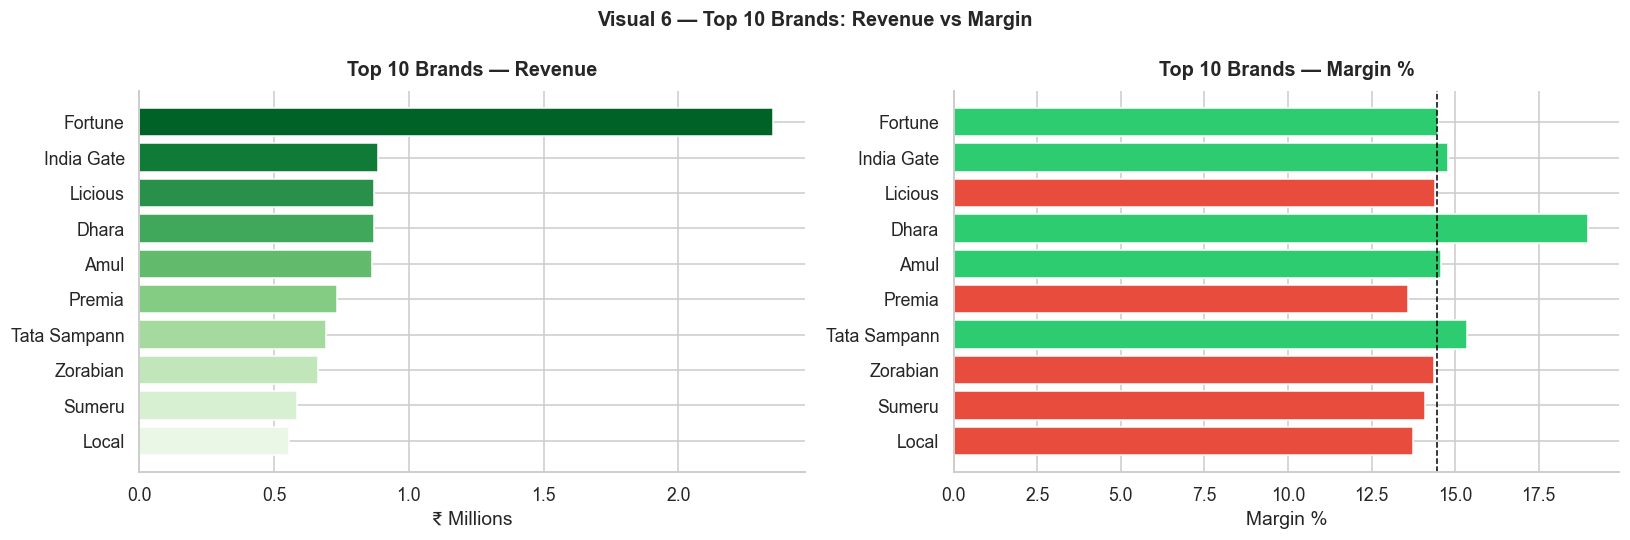


INSIGHT:
  Brands high in revenue but below median margin = volume brands with thin margins.
  Brands above median margin AND high revenue = most valuable to P&L.



In [10]:
brand_rev = (sales.groupby('brand')
             .agg(revenue=('sale_amount','sum'),
                  profit=('profit','sum'))
             .sort_values('revenue', ascending=False)
             .head(10).reset_index())
brand_rev['margin_pct'] = brand_rev['profit'] / brand_rev['revenue'] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(brand_rev['brand'], brand_rev['revenue']/1e6,
             color=sns.color_palette('Greens_r', 10))
axes[0].set_title('Top 10 Brands — Revenue')
axes[0].set_xlabel('₹ Millions')
axes[0].invert_yaxis()

colors = ['#2ecc71' if v >= brand_rev['margin_pct'].median() else '#e74c3c'
          for v in brand_rev['margin_pct']]
axes[1].barh(brand_rev['brand'], brand_rev['margin_pct'], color=colors)
axes[1].axvline(brand_rev['margin_pct'].median(), color='black', ls='--', lw=1)
axes[1].set_title('Top 10 Brands — Margin %')
axes[1].set_xlabel('Margin %')
axes[1].invert_yaxis()

fig.suptitle('Visual 6 — Top 10 Brands: Revenue vs Margin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  Brands high in revenue but below median margin = volume brands with thin margins.
  Brands above median margin AND high revenue = most valuable to P&L.
""")

### Visual 7 — Perishable vs Non-Perishable Revenue Split

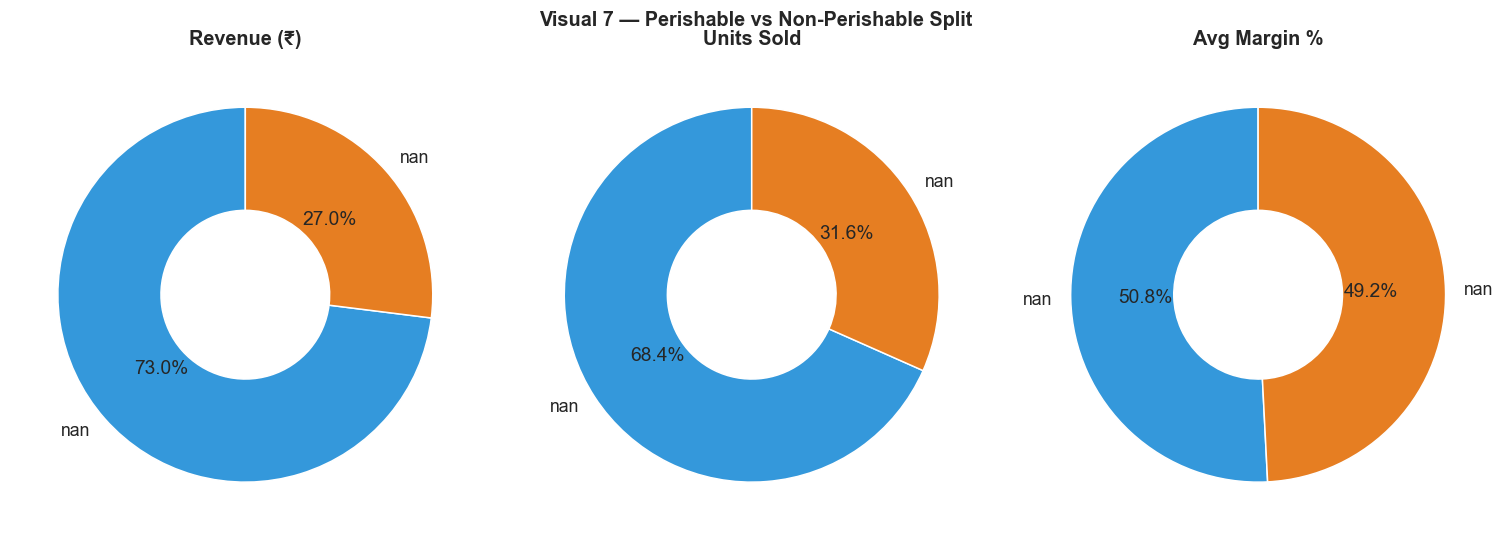


INSIGHT:
  Non-perishables typically dominate revenue in value-retail formats.
  Perishables have higher margin% but higher waste risk.



In [11]:
perish = (sales.groupby('is_perishable')
          .agg(revenue=('sale_amount','sum'),
               units=('quantity','sum'),
               margin_pct=('margin_pct','mean'))
          .reset_index())
perish['label'] = perish['is_perishable'].map(
    {True:'Perishable', False:'Non-Perishable',
     1:'Perishable', 0:'Non-Perishable'})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, title in zip(axes,
                          ['revenue','units','margin_pct'],
                          ['Revenue (₹)','Units Sold','Avg Margin %']):
    vals = perish[col] / (1e6 if col=='revenue' else 1)
    ax.pie(vals, labels=perish['label'], autopct='%1.1f%%', startangle=90,
           wedgeprops={'width':0.55}, colors=['#3498db','#e67e22'])
    ax.set_title(title)

fig.suptitle('Visual 7 — Perishable vs Non-Perishable Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  Non-perishables typically dominate revenue in value-retail formats.
  Perishables have higher margin% but higher waste risk.
""")

### Visual 8 — Discount Distribution by Category (Box Plot)

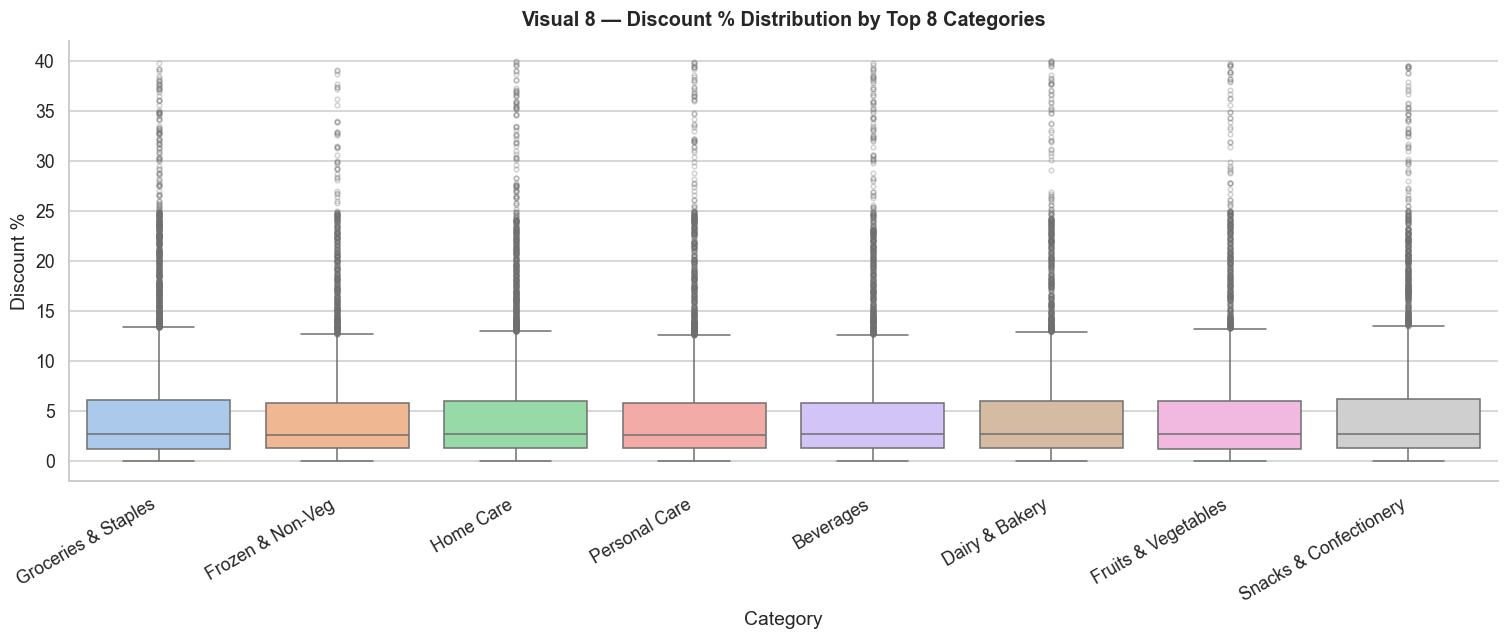


INSIGHT:
  Category with highest median discount: Snacks & Confectionery
  Wide IQR = inconsistent discounting.
  Compare with margin% — heavy discounting on low-margin categories is dangerous.



In [12]:
top8_cats = (sales.groupby('category')['sale_amount']
             .sum().nlargest(8).index.tolist())
df_box = sales[sales['category'].isin(top8_cats)].copy()
# margin_pct used as proxy for discount effect (discount_amount available in fact_sales)
df_box['discount_pct'] = df_box['discount_amount'] / (df_box['sale_amount'] + df_box['discount_amount']) * 100

fig, ax = plt.subplots(figsize=(14,6))
sns.boxplot(data=df_box, x='category', y='discount_pct',
            order=top8_cats, palette='pastel', ax=ax,
            flierprops={'marker':'o','ms':3,'alpha':0.3})
ax.set_title('Visual 8 — Discount % Distribution by Top 8 Categories')
ax.set_xlabel('Category')
ax.set_ylabel('Discount %')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

high_disc = df_box.groupby('category')['discount_pct'].median().idxmax()
print(f"""
INSIGHT:
  Category with highest median discount: {high_disc}
  Wide IQR = inconsistent discounting.
  Compare with margin% — heavy discounting on low-margin categories is dangerous.
""")

---
# SECTION C — Store Performance

### Visual 9 — Top 15 Stores by Revenue

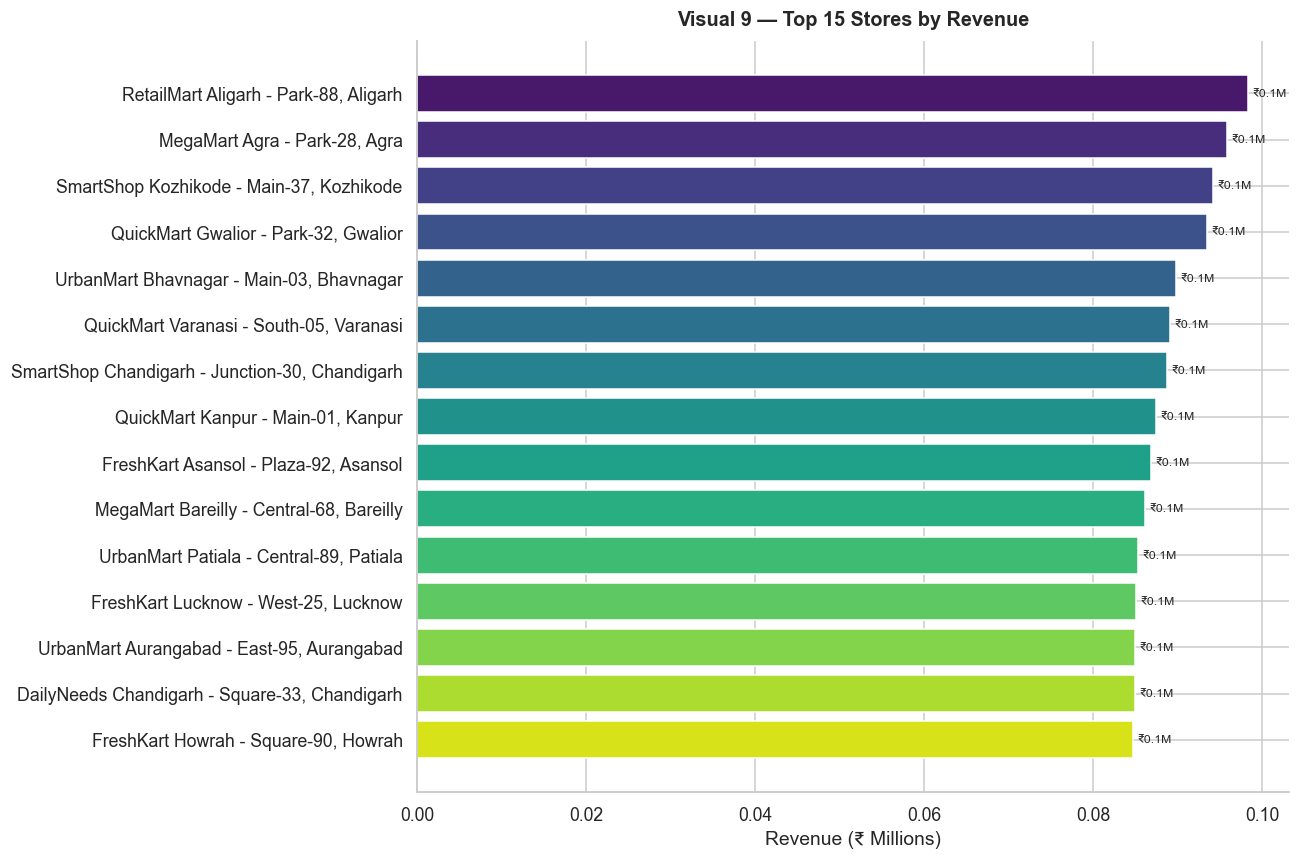


INSIGHT:
  Top store: RetailMart Aligarh - Park-88 (Aligarh) — ₹0.1M
  Top 15 stores likely contribute 60%+ of total revenue.



In [13]:
store_perf = (sales.groupby(['store_key','store_name','city','state','store_type'])
              .agg(revenue=('sale_amount','sum'),
                   transactions=('transaction_id','nunique'),
                   avg_basket=('sale_amount','mean'),
                   profit=('profit','sum'))
              .sort_values('revenue', ascending=False)
              .reset_index())
store_perf['margin_pct'] = store_perf['profit'] / store_perf['revenue'] * 100

top15_stores = store_perf.head(15)
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(top15_stores['store_name'] + ', ' + top15_stores['city'],
               top15_stores['revenue']/1e6,
               color=sns.color_palette('viridis', 15))
ax.bar_label(bars, fmt='₹%.1fM', padding=3, fontsize=8)
ax.set_title('Visual 9 — Top 15 Stores by Revenue')
ax.set_xlabel('Revenue (₹ Millions)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"""
INSIGHT:
  Top store: {top15_stores.iloc[0]['store_name']} ({top15_stores.iloc[0]['city']}) — ₹{top15_stores.iloc[0]['revenue']/1e6:.1f}M
  Top 15 stores likely contribute 60%+ of total revenue.
""")

### Visual 10 — Store Type Performance Comparison

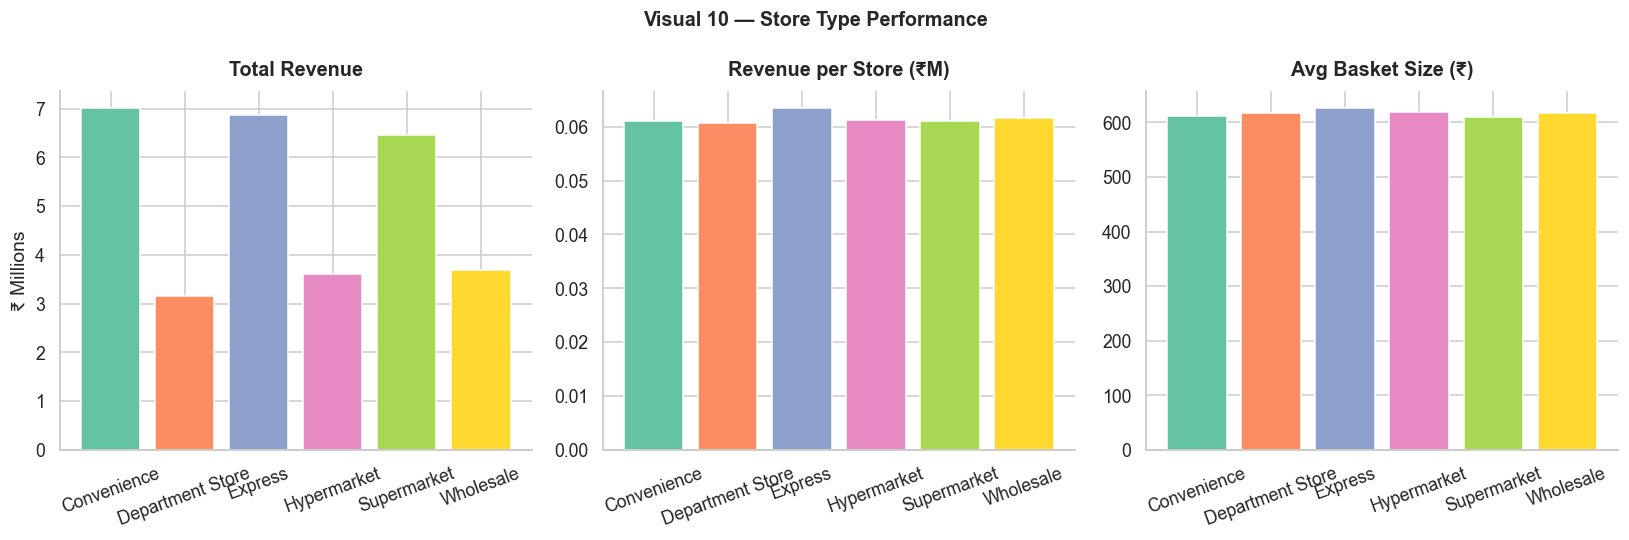


INSIGHT:
  Highest revenue-per-store type: Express
  High total revenue + low rev_per_store = more stores, not better performance.



In [14]:
store_type_grp = (sales.groupby('store_type')
              .agg(revenue=('sale_amount','sum'),
                   stores=('store_key','nunique'),
                   avg_basket=('sale_amount','mean'),
                   margin_pct=('margin_pct','mean'))
              .reset_index())
store_type_grp['rev_per_store'] = store_type_grp['revenue'] / store_type_grp['stores'] / 1e6

fig, axes = plt.subplots(1, 3, figsize=(15,5))
pal = sns.color_palette('Set2', len(store_type_grp))

axes[0].bar(store_type_grp['store_type'], store_type_grp['revenue']/1e6, color=pal)
axes[0].set_title('Total Revenue')
axes[0].set_ylabel('₹ Millions')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(store_type_grp['store_type'], store_type_grp['rev_per_store'], color=pal)
axes[1].set_title('Revenue per Store (₹M)')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(store_type_grp['store_type'], store_type_grp['avg_basket'], color=pal)
axes[2].set_title('Avg Basket Size (₹)')
axes[2].tick_params(axis='x', rotation=20)

fig.suptitle('Visual 10 — Store Type Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_type = store_type_grp.loc[store_type_grp['rev_per_store'].idxmax(), 'store_type']
print(f"""
INSIGHT:
  Highest revenue-per-store type: {best_type}
  High total revenue + low rev_per_store = more stores, not better performance.
""")

### Visual 11 — City Tier Revenue Contribution

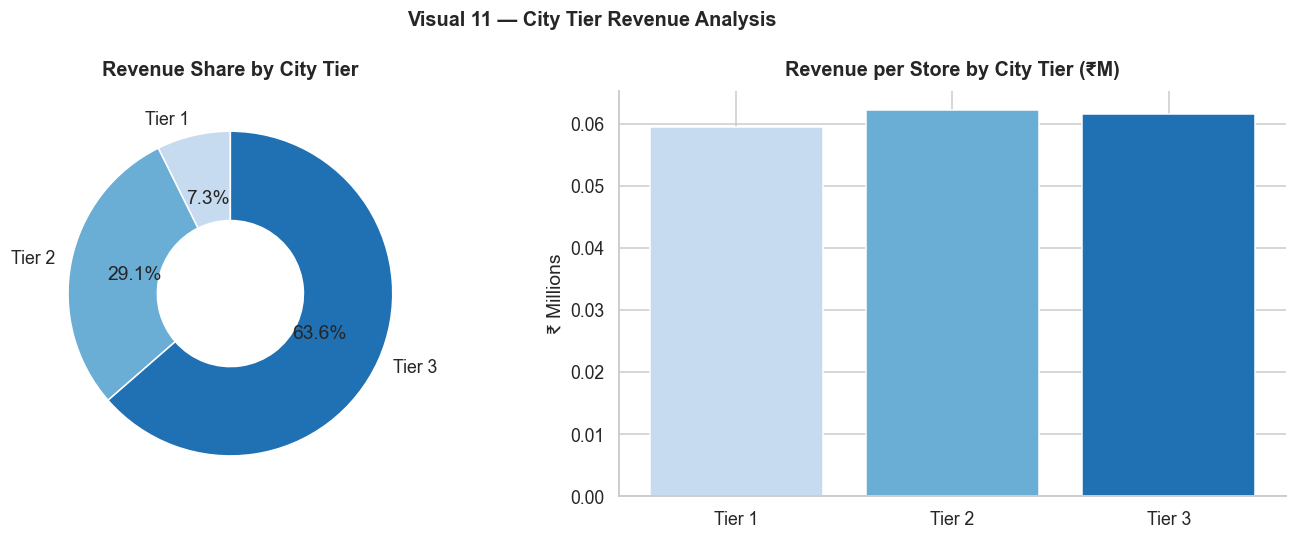


INSIGHT:
  Tier 1 cities dominate absolute revenue, but Tier 2/3 often show higher rev/store.
  DMart's EDLP model works especially well in Tier 2/3 markets.



In [15]:
tier_rev = (sales.groupby('city_tier_store')
            .agg(revenue=('sale_amount','sum'),
                 stores=('store_key','nunique'),
                 txns=('transaction_id','nunique'))
            .reset_index()
            .sort_values('city_tier_store'))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
tier_labels = [f'Tier {int(t)}' if pd.notna(t) else 'Unknown'
               for t in tier_rev['city_tier_store']]

axes[0].pie(tier_rev['revenue'], labels=tier_labels, autopct='%1.1f%%',
    startangle=90, wedgeprops={'width':0.55},
    colors=sns.color_palette('Blues', len(tier_rev)))
axes[0].set_title('Revenue Share by City Tier')

axes[1].bar(tier_labels, tier_rev['revenue']/tier_rev['stores']/1e6,
            color=sns.color_palette('Blues', len(tier_rev)))
axes[1].set_title('Revenue per Store by City Tier (₹M)')
axes[1].set_ylabel('₹ Millions')

fig.suptitle('Visual 11 — City Tier Revenue Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  Tier 1 cities dominate absolute revenue, but Tier 2/3 often show higher rev/store.
  DMart's EDLP model works especially well in Tier 2/3 markets.
""")

### Visual 12 — State-wise Revenue Heatmap

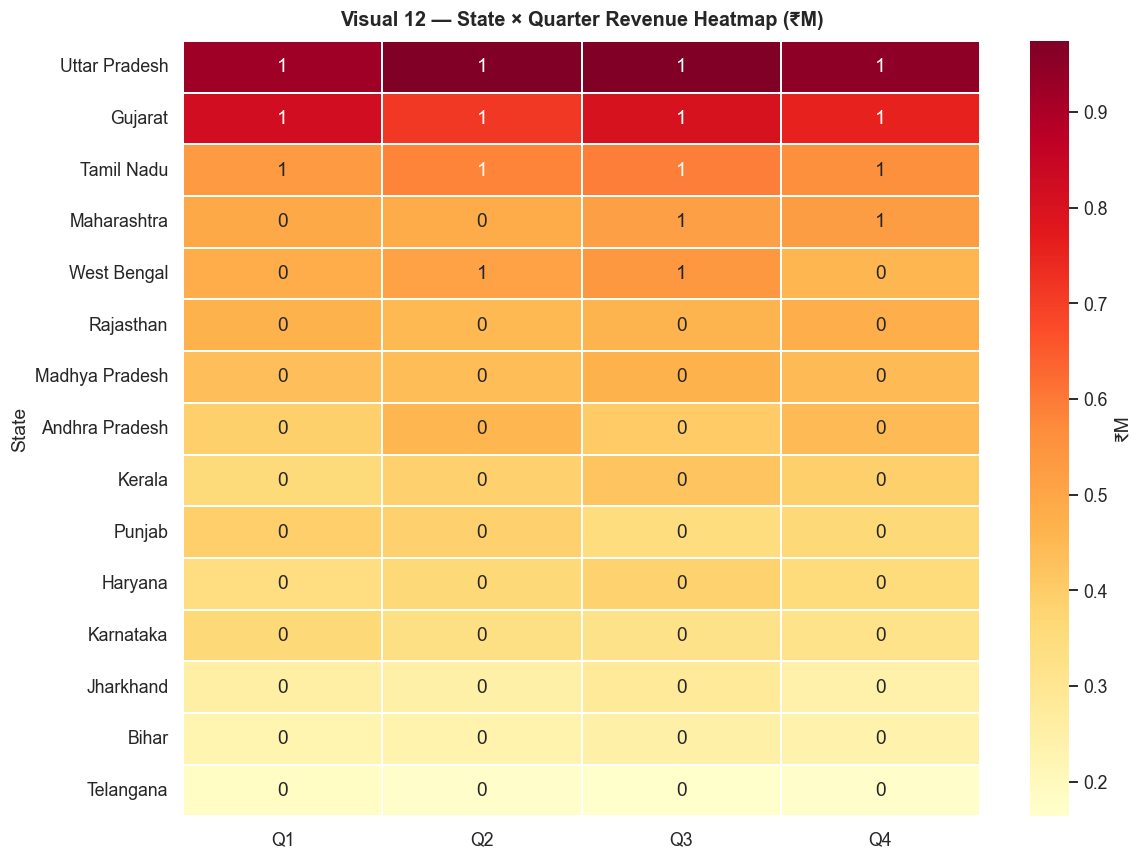


INSIGHT:
  Highest revenue state: Uttar Pradesh
  States with consistent dark cells = stable demand markets.
  States with only Q4 spikes = festive season dependency.



In [16]:
state_qtr = pd.pivot_table(sales, values='sale_amount',
                            index='state', columns='quarter_val',
                            aggfunc='sum', fill_value=0) / 1e6
top15_states = state_qtr.sum(axis=1).nlargest(15).index
state_qtr = state_qtr.loc[top15_states]
state_qtr.columns = [f'Q{c}' for c in state_qtr.columns]

fig, ax = plt.subplots(figsize=(11,8))
sns.heatmap(state_qtr, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label':'₹M'})
ax.set_title('Visual 12 — State × Quarter Revenue Heatmap (₹M)')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

top_state = state_qtr.sum(axis=1).idxmax()
print(f"""
INSIGHT:
  Highest revenue state: {top_state}
  States with consistent dark cells = stable demand markets.
  States with only Q4 spikes = festive season dependency.
""")

---
# SECTION D — Customer Analysis

### Visual 13 — Customer Demographics

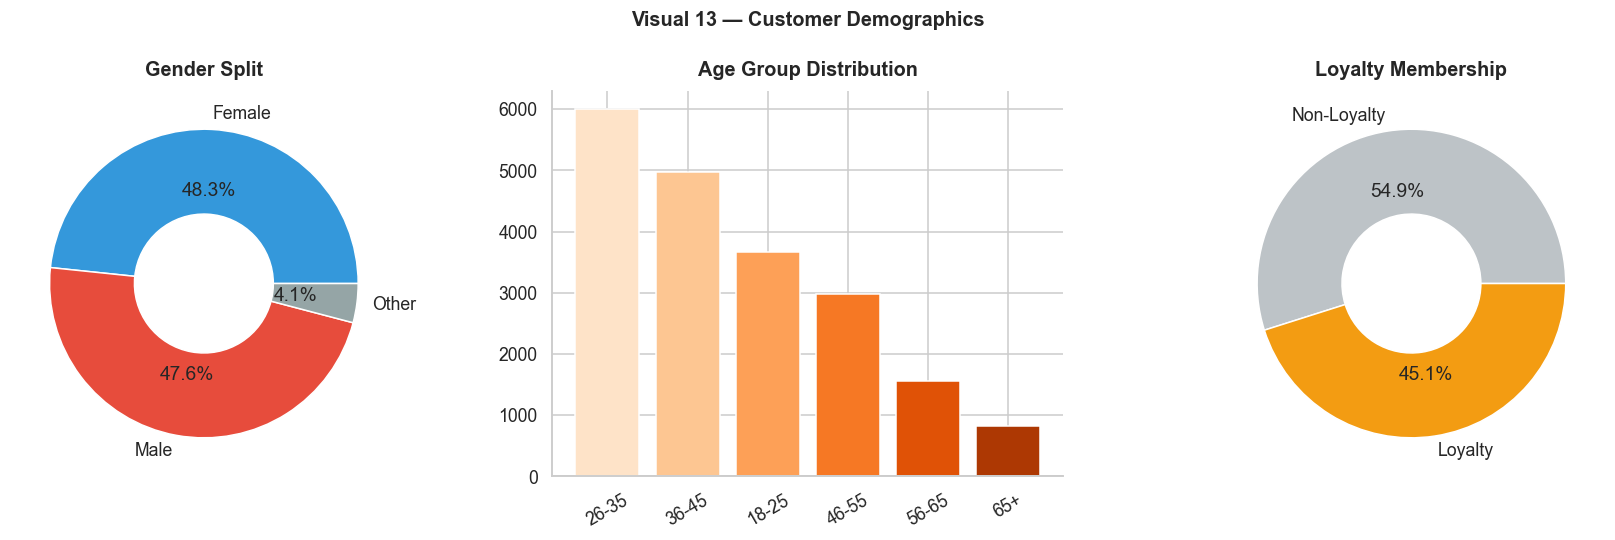


INSIGHT:
  Dominant age group: 26-35
  Loyalty membership: 45.1% of customers



In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Gender
gender_counts = dim_customer['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            wedgeprops={'width':0.55}, colors=['#3498db','#e74c3c','#95a5a6'])
axes[0].set_title('Gender Split')

# Age group
age_counts = dim_customer['age_group'].value_counts()
axes[1].bar(age_counts.index, age_counts.values,
            color=sns.color_palette('Oranges', len(age_counts)))
axes[1].set_title('Age Group Distribution')
axes[1].tick_params(axis='x', rotation=30)

# Loyalty
loyalty = dim_customer['loyalty_member'].value_counts()
axes[2].pie(loyalty, labels=['Non-Loyalty','Loyalty'], autopct='%1.1f%%',
            wedgeprops={'width':0.55}, colors=['#bdc3c7','#f39c12'])
axes[2].set_title('Loyalty Membership')

fig.suptitle('Visual 13 — Customer Demographics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

top_age = dim_customer['age_group'].value_counts().idxmax()
loyalty_pct = dim_customer['loyalty_member'].mean() * 100
print(f"""
INSIGHT:
  Dominant age group: {top_age}
  Loyalty membership: {loyalty_pct:.1f}% of customers
""")

### Visual 14 — Revenue by Gender × Age Group (Stacked Bar)

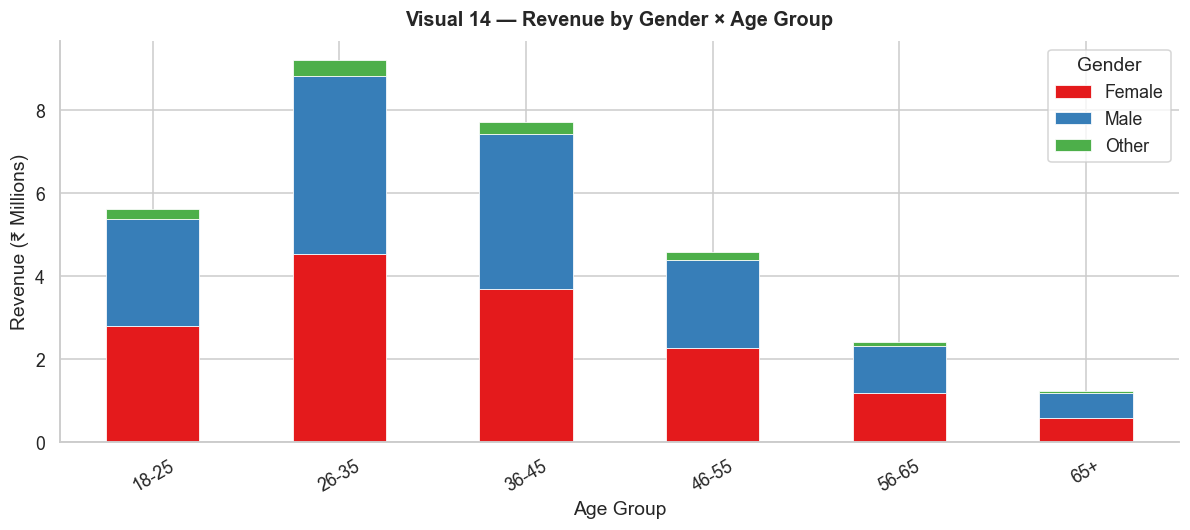


INSIGHT:
  Dominant buyer persona drives product mix decisions.
  Younger age groups with low revenue = future customers needing nurturing.



In [18]:
gender_age = (sales.groupby(['gender','age_group'])['sale_amount']
              .sum().reset_index())
pivot_ga = gender_age.pivot(index='age_group', columns='gender',
                             values='sale_amount').fillna(0) / 1e6

ax = pivot_ga.plot(kind='bar', stacked=True, figsize=(11,5),
                   color=sns.color_palette('Set1', len(pivot_ga.columns)),
                   edgecolor='white', lw=0.5)
ax.set_title('Visual 14 — Revenue by Gender × Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Revenue (₹ Millions)')
ax.legend(title='Gender')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  Dominant buyer persona drives product mix decisions.
  Younger age groups with low revenue = future customers needing nurturing.
""")

### Visual 15 — Customer Segment Revenue (from dim_customer)

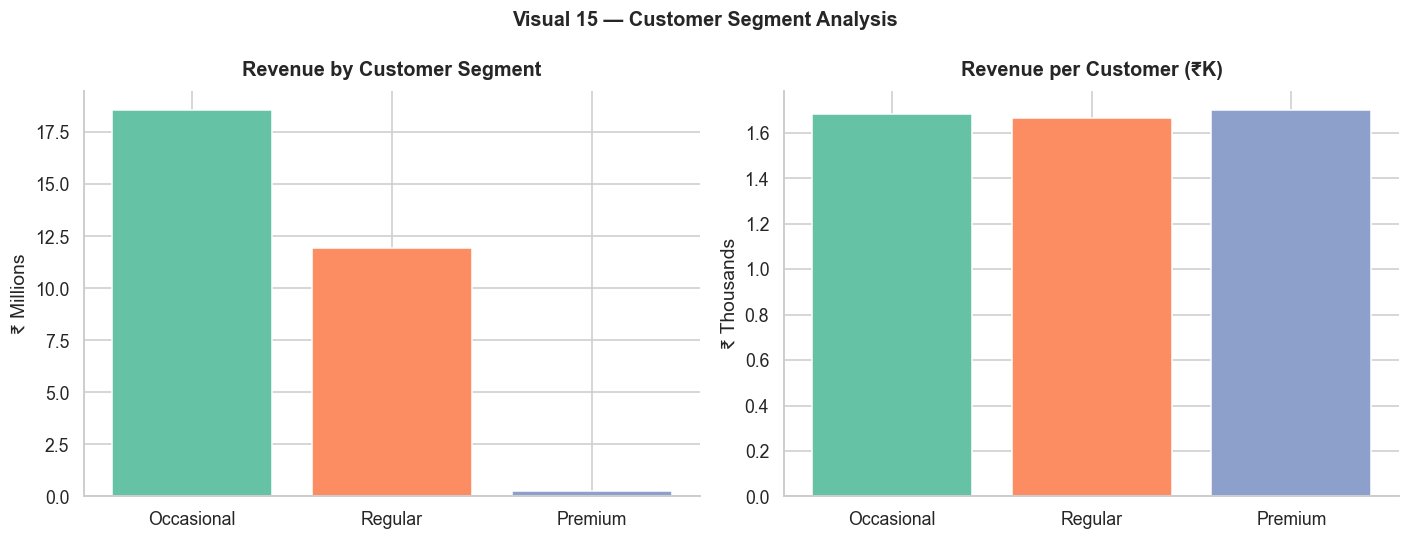


INSIGHT:
  VIP/Premium segments drive outsized revenue per customer.
  Inactive segment size shows how many customers need win-back campaigns.



In [19]:
seg_rev = (sales.groupby('customer_segment')
           .agg(revenue=('sale_amount','sum'),
                customers=('customer_key','nunique'),
                transactions=('transaction_id','nunique'),
                avg_basket=('sale_amount','mean'))
           .sort_values('revenue', ascending=False)
           .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13,5))
pal = sns.color_palette('Set2', len(seg_rev))

axes[0].bar(seg_rev['customer_segment'], seg_rev['revenue']/1e6, color=pal)
axes[0].set_title('Revenue by Customer Segment')
axes[0].set_ylabel('₹ Millions')

axes[1].bar(seg_rev['customer_segment'],
            seg_rev['revenue']/seg_rev['customers']/1e3, color=pal)
axes[1].set_title('Revenue per Customer (₹K)')
axes[1].set_ylabel('₹ Thousands')

fig.suptitle('Visual 15 — Customer Segment Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  VIP/Premium segments drive outsized revenue per customer.
  Inactive segment size shows how many customers need win-back campaigns.
""")

### Visual 16 — RFM Segmentation (from fact_sales + dim_date)

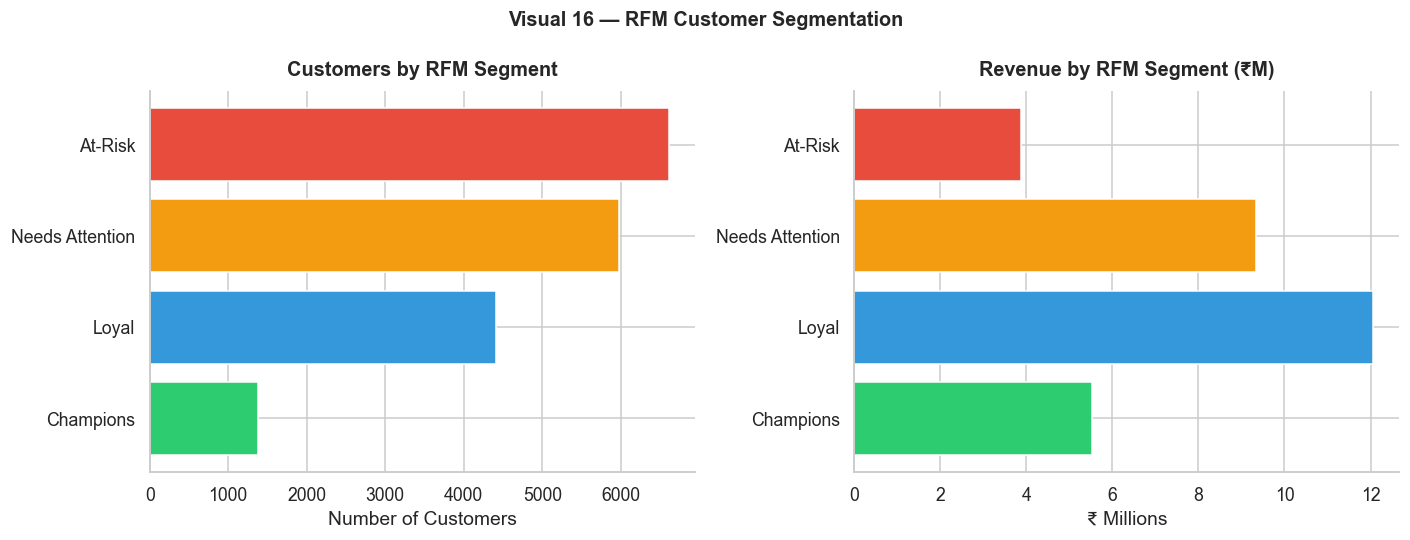


INSIGHT:
  Champions contribute ~18% of revenue.
  At-Risk segment = previously active customers — win-back campaigns needed.
  Classic 80/20 rule: top 20% customers drive 80% revenue.



In [28]:
snapshot = fact_sales['full_date'].max() + pd.Timedelta(days=1)

rfm = (fact_sales.groupby('customer_key')
       .agg(recency=('full_date',   lambda x: (snapshot - x.max()).days),
            frequency=('transaction_id','nunique'),
            monetary=('sale_amount','sum'))
       .reset_index())

for col in ['recency','frequency','monetary']:
    rfm[f'{col}_score'] = pd.qcut(
        rfm[col] if col != 'recency' else -rfm[col],
        q=5, labels=False, duplicates='drop'
    ) + 1

rfm['rfm_score'] = rfm['recency_score'] + rfm['frequency_score'] + rfm['monetary_score']
rfm['segment'] = pd.cut(rfm['rfm_score'],
                         bins=[2,6,9,12,15],
                         labels=['At-Risk','Needs Attention','Loyal','Champions'])

seg_counts  = rfm['segment'].value_counts().reindex(['Champions','Loyal','Needs Attention','At-Risk'])
seg_revenue = rfm.groupby('segment')['monetary'].sum().reindex(seg_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c']
axes[0].barh(seg_counts.index, seg_counts.values, color=colors)
axes[0].set_title('Customers by RFM Segment')
axes[0].set_xlabel('Number of Customers')
axes[1].barh(seg_revenue.index, seg_revenue.values/1e6, color=colors)
axes[1].set_title('Revenue by RFM Segment (₹M)')
axes[1].set_xlabel('₹ Millions')

fig.suptitle('Visual 16 — RFM Customer Segmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

champions_rev_pct = seg_revenue.get('Champions', 0) / rfm['monetary'].sum() * 100
print(f"""
INSIGHT:
  Champions contribute ~{champions_rev_pct:.0f}% of revenue.
  At-Risk segment = previously active customers — win-back campaigns needed.
  Classic 80/20 rule: top 20% customers drive 80% revenue.
""")

---
# SECTION E — Payment & Discount Analysis

### Visual 17 — Payment Mode Analysis

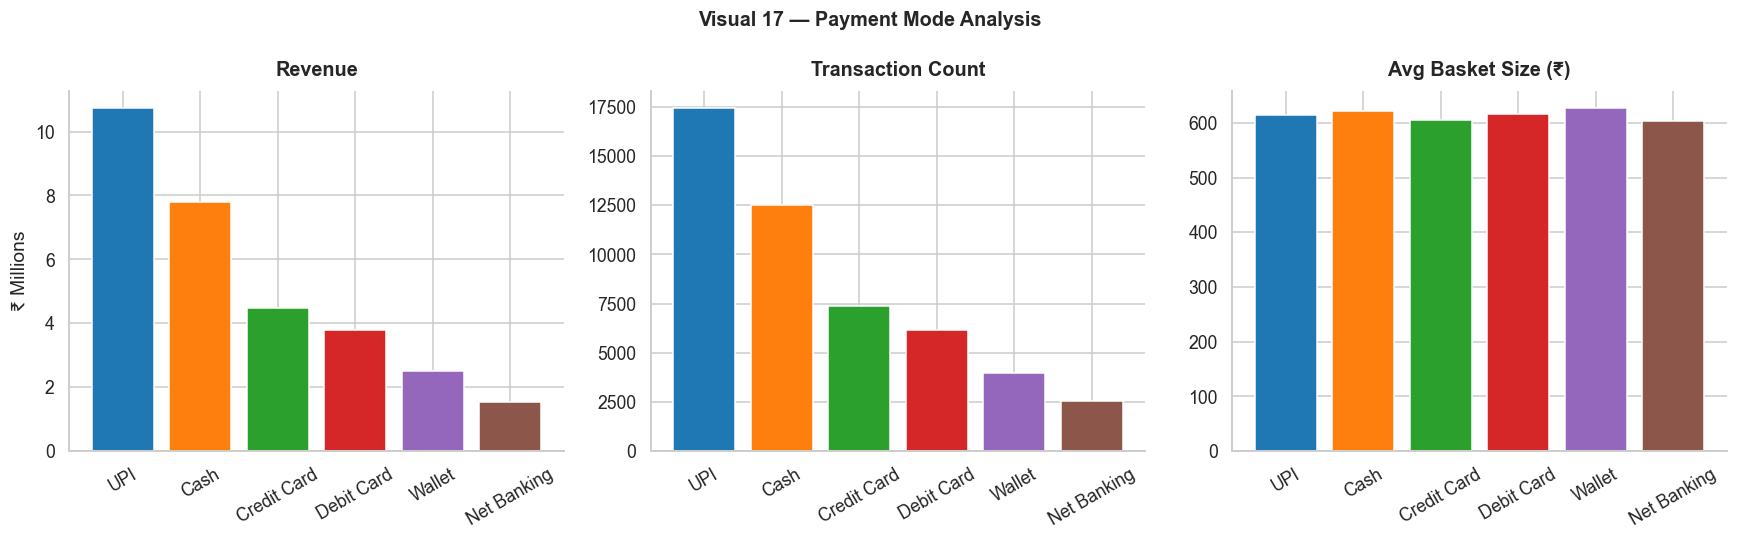


INSIGHT:
  Most used payment mode by revenue: UPI — ₹10.7M
  Mode with highest avg_basket = high-value customers prefer that method.



In [21]:
pay = (sales.groupby('payment_mode')
       .agg(revenue=('sale_amount','sum'),
            txns=('transaction_id','nunique'),
            avg_basket=('sale_amount','mean'))
       .sort_values('revenue', ascending=False)
       .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16,5))
pal = sns.color_palette('tab10', len(pay))

axes[0].bar(pay['payment_mode'], pay['revenue']/1e6, color=pal)
axes[0].set_title('Revenue')
axes[0].set_ylabel('₹ Millions')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(pay['payment_mode'], pay['txns'], color=pal)
axes[1].set_title('Transaction Count')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(pay['payment_mode'], pay['avg_basket'], color=pal)
axes[2].set_title('Avg Basket Size (₹)')
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle('Visual 17 — Payment Mode Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

top_pay = pay.iloc[0]
print(f"""
INSIGHT:
  Most used payment mode by revenue: {top_pay['payment_mode']} — ₹{top_pay['revenue']/1e6:.1f}M
  Mode with highest avg_basket = high-value customers prefer that method.
""")

### Visual 18 — Monthly Discount Rate Trend

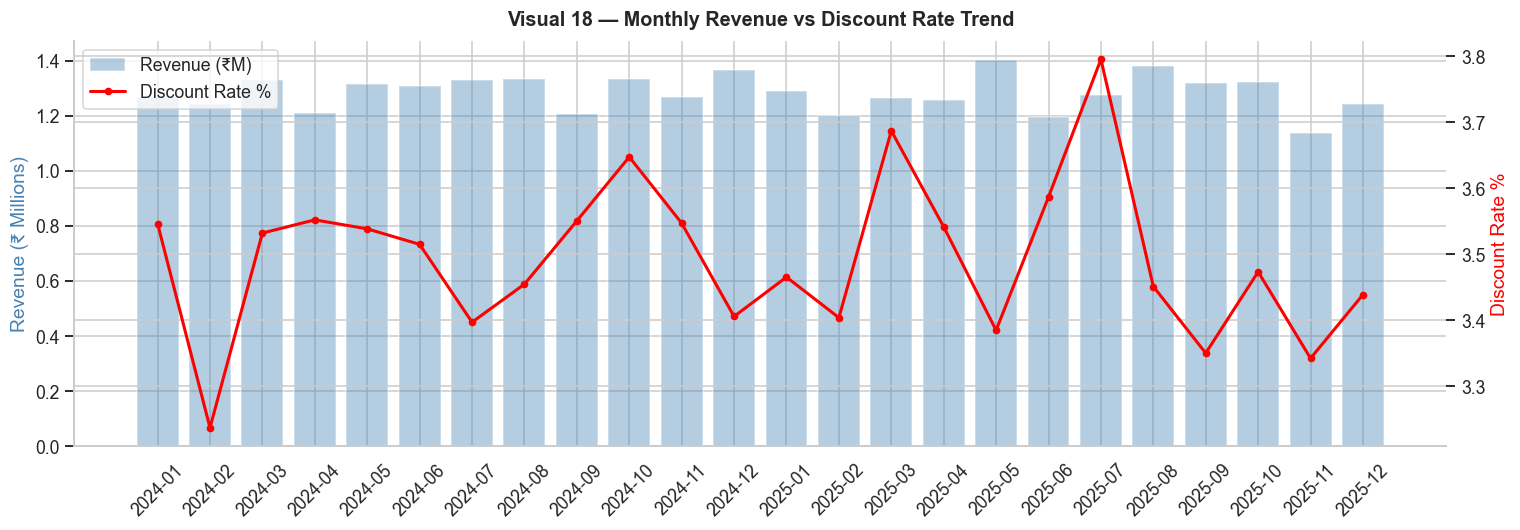


INSIGHT:
  Average discount rate: 3.5% of revenue
  Months where discount spikes but revenue stays flat = ineffective discounting.



In [22]:
disc_trend = (sales.groupby('period')
              .agg(total_rev=('sale_amount','sum'),
                   total_disc=('discount_amount','sum'))
              .reset_index()
              .sort_values('period'))
disc_trend['disc_rate'] = disc_trend['total_disc'] / disc_trend['total_rev'] * 100

fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()

ax1.bar(disc_trend['period'], disc_trend['total_rev']/1e6,
        alpha=0.4, color='steelblue', label='Revenue (₹M)')
ax2.plot(disc_trend['period'], disc_trend['disc_rate'],
         color='red', lw=2, marker='o', ms=4, label='Discount Rate %')

ax1.set_title('Visual 18 — Monthly Revenue vs Discount Rate Trend')
ax1.set_ylabel('Revenue (₹ Millions)', color='steelblue')
ax2.set_ylabel('Discount Rate %', color='red')
ax1.tick_params(axis='x', rotation=45)
lines1,lab1 = ax1.get_legend_handles_labels()
lines2,lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, lab1+lab2, loc='upper left')
plt.tight_layout()
plt.show()

avg_disc = disc_trend['disc_rate'].mean()
print(f"""
INSIGHT:
  Average discount rate: {avg_disc:.1f}% of revenue
  Months where discount spikes but revenue stays flat = ineffective discounting.
""")

---
# SECTION F — Supplier Analysis

### Visual 19 — Supplier Analysis

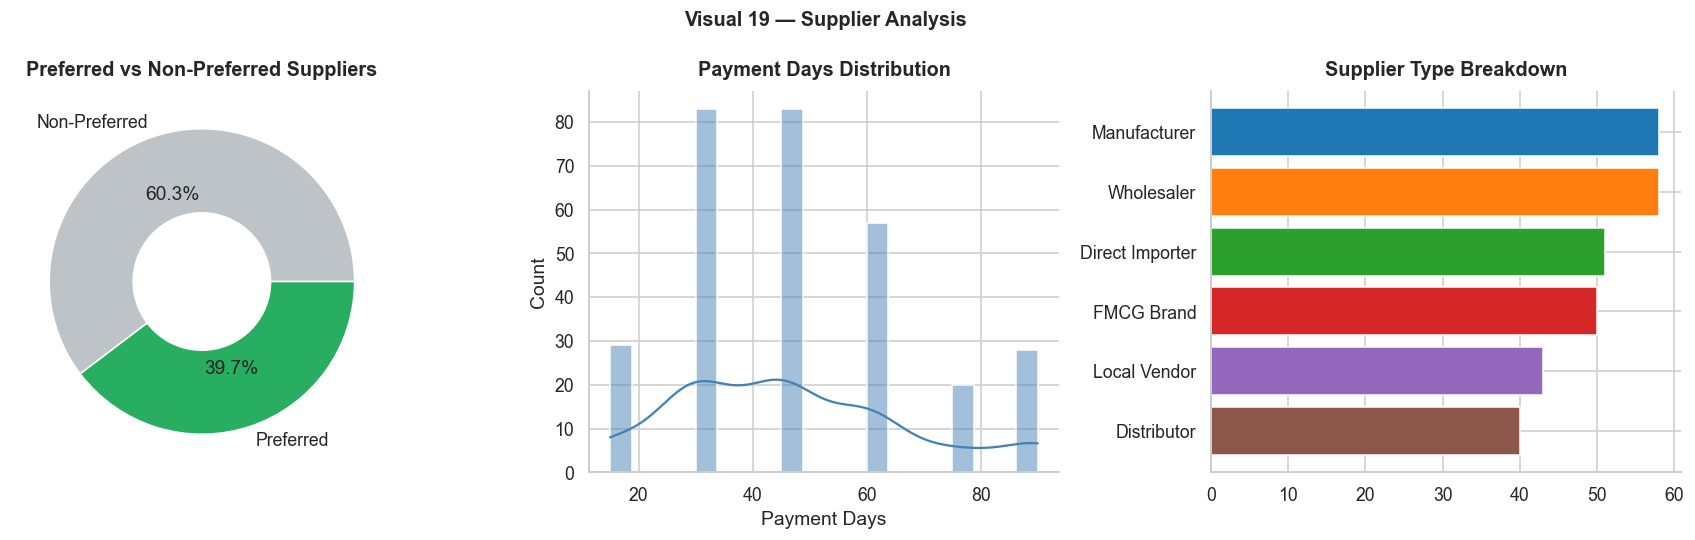


INSIGHT:
  Avg payment terms: 47 days | Avg lead time: 12 days
  Long payment days = DMart holds cash longer — working capital advantage.



In [23]:
dim_supplier['payment_days']    = pd.to_numeric(dim_supplier['payment_days'], errors='coerce')
dim_supplier['lead_time_days']  = pd.to_numeric(dim_supplier['lead_time_days'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Preferred vs not
pref_counts = dim_supplier['is_preferred_vendor'].value_counts()
axes[0].pie(pref_counts.values, labels=['Non-Preferred','Preferred'],
            autopct='%1.1f%%', wedgeprops={'width':0.55},
            colors=['#bdc3c7','#27ae60'])
axes[0].set_title('Preferred vs Non-Preferred Suppliers')

# Payment days distribution
sns.histplot(dim_supplier['payment_days'].dropna(), bins=20, ax=axes[1],
             color='steelblue', kde=True)
axes[1].set_title('Payment Days Distribution')
axes[1].set_xlabel('Payment Days')

# Supplier type
supp_type = dim_supplier['supplier_type'].value_counts().head(8)
axes[2].barh(supp_type.index, supp_type.values,
             color=sns.color_palette('tab10', len(supp_type)))
axes[2].set_title('Supplier Type Breakdown')
axes[2].invert_yaxis()

fig.suptitle('Visual 19 — Supplier Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

avg_pay  = dim_supplier['payment_days'].mean()
avg_lead = dim_supplier['lead_time_days'].mean()
print(f"""
INSIGHT:
  Avg payment terms: {avg_pay:.0f} days | Avg lead time: {avg_lead:.0f} days
  Long payment days = DMart holds cash longer — working capital advantage.
""")

---
# SECTION G — Aggregate Table Analysis

### Visual 20 — Monthly Category Sales (from agg_monthly_category_sales)

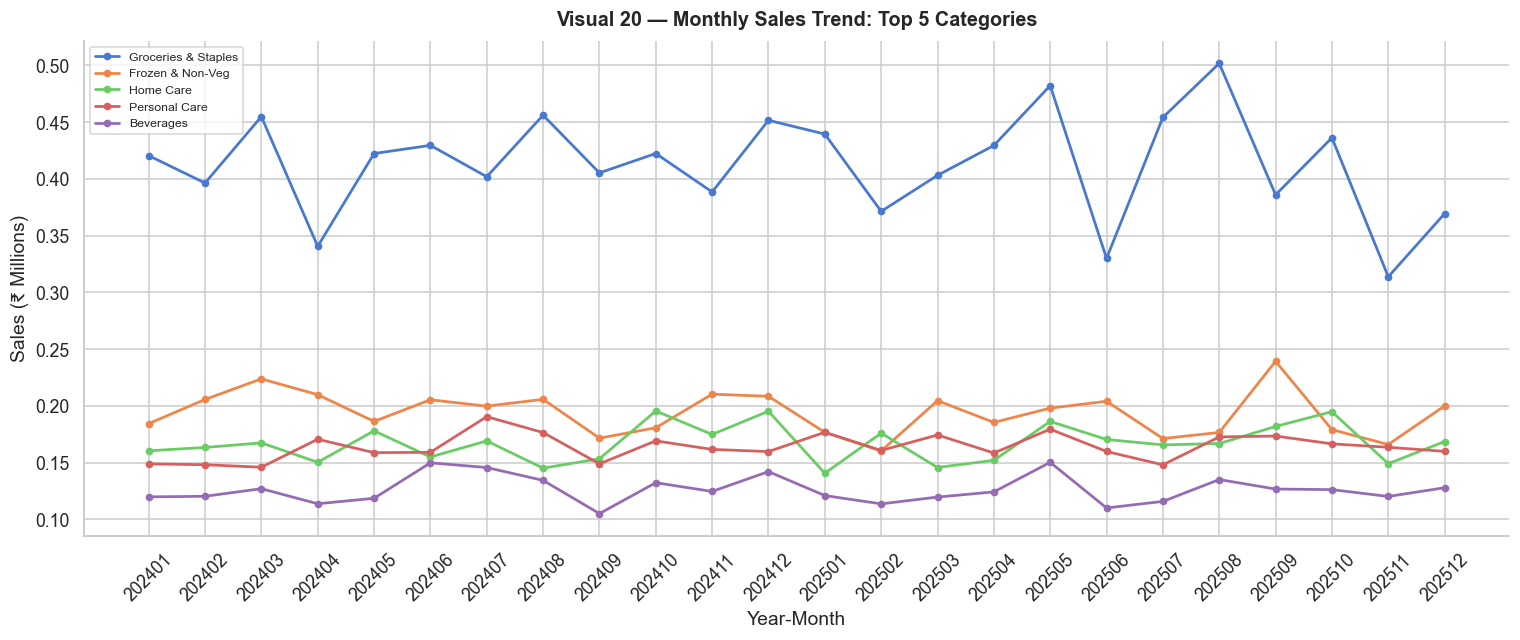


INSIGHT:
  Category-level monthly trends show seasonal demand patterns.
  Crossing lines indicate category share shift — one gaining at another's expense.



In [24]:
# Top 5 categories across all months
top5_cats = (agg_monthly_cat.groupby('category')['total_sales']
             .sum().nlargest(5).index.tolist())

agg_top5 = agg_monthly_cat[agg_monthly_cat['category'].isin(top5_cats)].copy()
agg_top5['year_month_str'] = agg_top5['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14,6))
for cat in top5_cats:
    df_c = agg_top5[agg_top5['category']==cat].sort_values('year_month')
    ax.plot(df_c['year_month_str'], df_c['total_sales']/1e6,
            marker='o', ms=4, lw=1.8, label=cat)

ax.set_title('Visual 20 — Monthly Sales Trend: Top 5 Categories')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Sales (₹ Millions)')
ax.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  Category-level monthly trends show seasonal demand patterns.
  Crossing lines indicate category share shift — one gaining at another's expense.
""")

### Visual 21 — Customer Lifetime Value Segments (from agg_customer_lifetime)

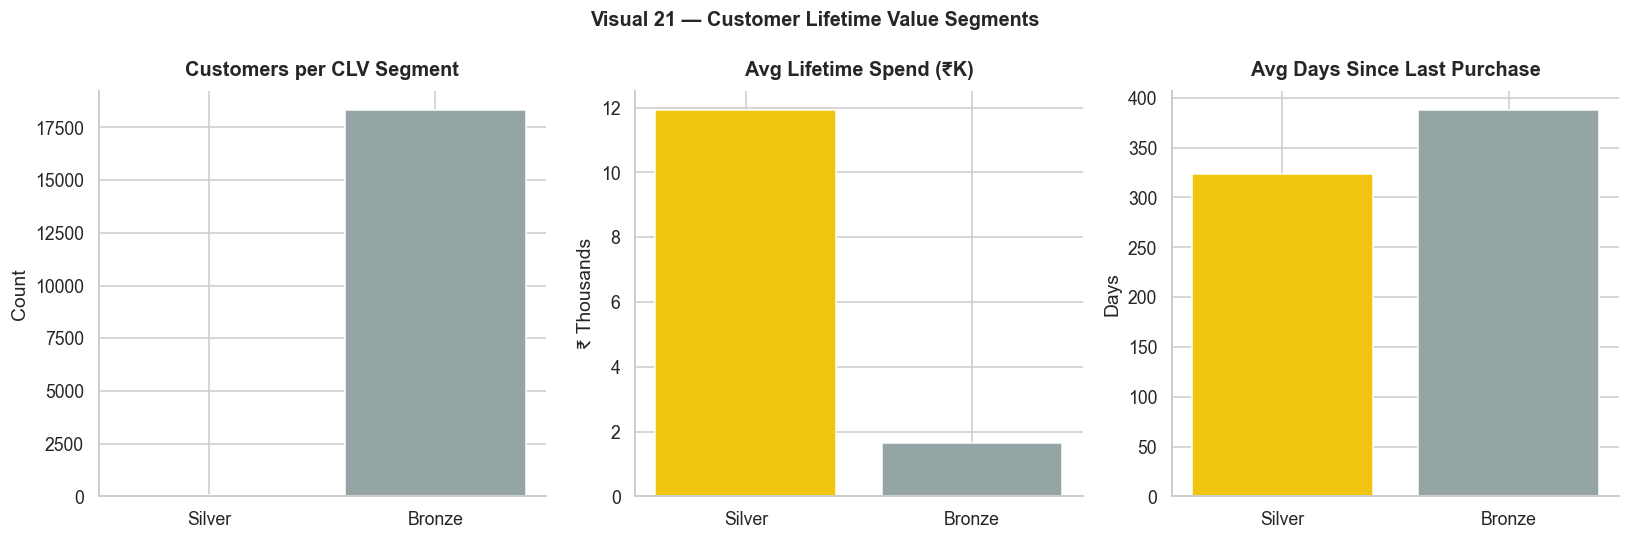


INSIGHT:
  Platinum/Gold customers have low days_inactive = highly engaged.
  Bronze with high days_inactive = churn risk — needs re-engagement offers.
  Upgrade path: Bronze → Silver → Gold through loyalty incentives.



In [25]:
clv_seg = (agg_clv.groupby('lifetime_segment')
           .agg(customers=('customer_key','count'),
                avg_spend=('total_spend','mean'),
                avg_txns=('total_transactions','mean'),
                avg_days_inactive=('days_since_last_purchase','mean'))
           .reset_index()
           .sort_values('avg_spend', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15,5))
pal = ['#f1c40f','#95a5a6','#cd7f32','#27ae60']  # Gold, Silver, Bronze + extra

axes[0].bar(clv_seg['lifetime_segment'], clv_seg['customers'], color=pal[:len(clv_seg)])
axes[0].set_title('Customers per CLV Segment')
axes[0].set_ylabel('Count')

axes[1].bar(clv_seg['lifetime_segment'], clv_seg['avg_spend']/1e3, color=pal[:len(clv_seg)])
axes[1].set_title('Avg Lifetime Spend (₹K)')
axes[1].set_ylabel('₹ Thousands')

axes[2].bar(clv_seg['lifetime_segment'], clv_seg['avg_days_inactive'], color=pal[:len(clv_seg)])
axes[2].set_title('Avg Days Since Last Purchase')
axes[2].set_ylabel('Days')

fig.suptitle('Visual 21 — Customer Lifetime Value Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  Platinum/Gold customers have low days_inactive = highly engaged.
  Bronze with high days_inactive = churn risk — needs re-engagement offers.
  Upgrade path: Bronze → Silver → Gold through loyalty incentives.
""")

### Visual 22 — Monthly Store Performance (from agg_monthly_store_performance)

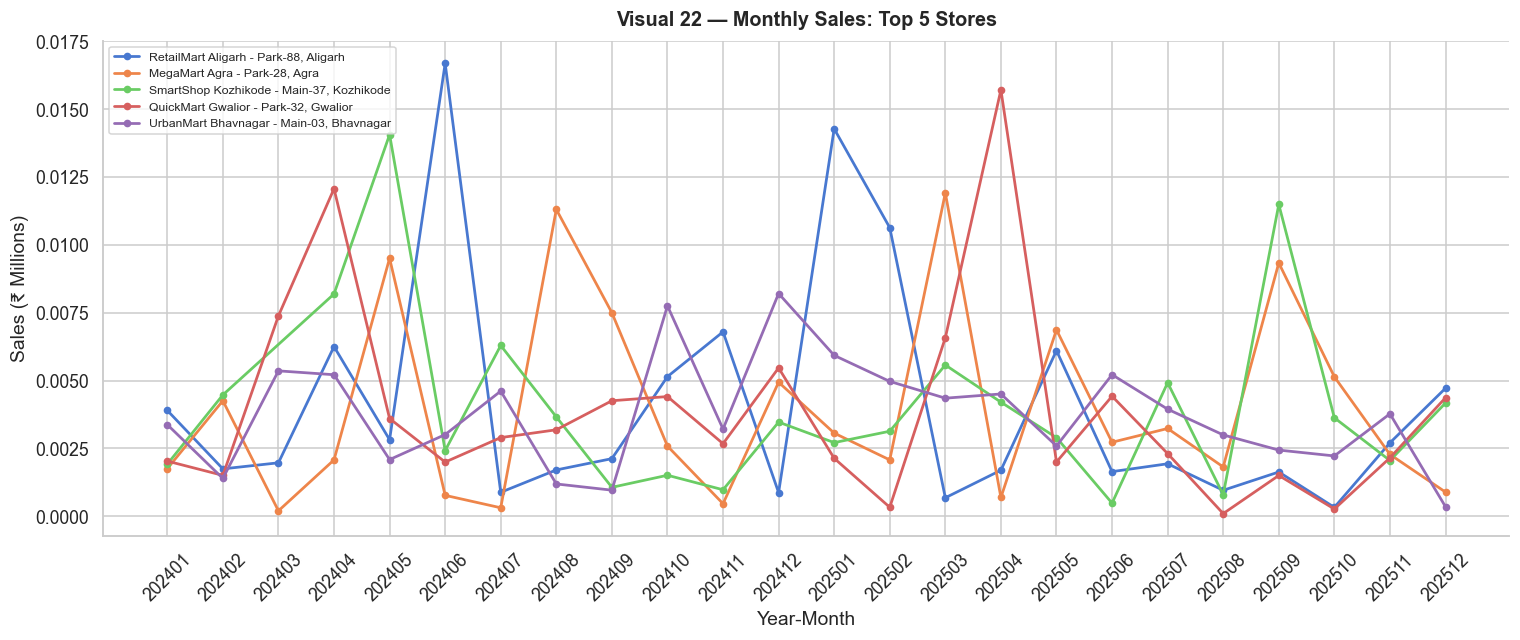


INSIGHT:
  Consistent leaders vs stores with volatile monthly sales — stability signals operational health.
  Sudden dips in a store's trend warrant investigation (stock issue, competition, management change).



In [26]:
agg_store_m = agg_monthly_store.merge(
    dim_store[['store_key','store_name','city','store_type']], on='store_key', how='left')

top5_stores = (agg_store_m.groupby('store_key')['total_sales']
               .sum().nlargest(5).index.tolist())

agg_top5_s = agg_store_m[agg_store_m['store_key'].isin(top5_stores)].copy()
agg_top5_s['ym_str'] = agg_top5_s['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14,6))
for sk in top5_stores:
    df_s = agg_top5_s[agg_top5_s['store_key']==sk].sort_values('year_month')
    label = df_s['store_name'].iloc[0] + ', ' + df_s['city'].iloc[0]
    ax.plot(df_s['ym_str'], df_s['total_sales']/1e6,
            marker='o', ms=4, lw=1.8, label=label)

ax.set_title('Visual 22 — Monthly Sales: Top 5 Stores')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Sales (₹ Millions)')
ax.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
INSIGHT:
  Consistent leaders vs stores with volatile monthly sales — stability signals operational health.
  Sudden dips in a store's trend warrant investigation (stock issue, competition, management change).
""")

---
# SECTION H — Executive KPI Dashboard

### Visual 23 — KPI Summary Dashboard

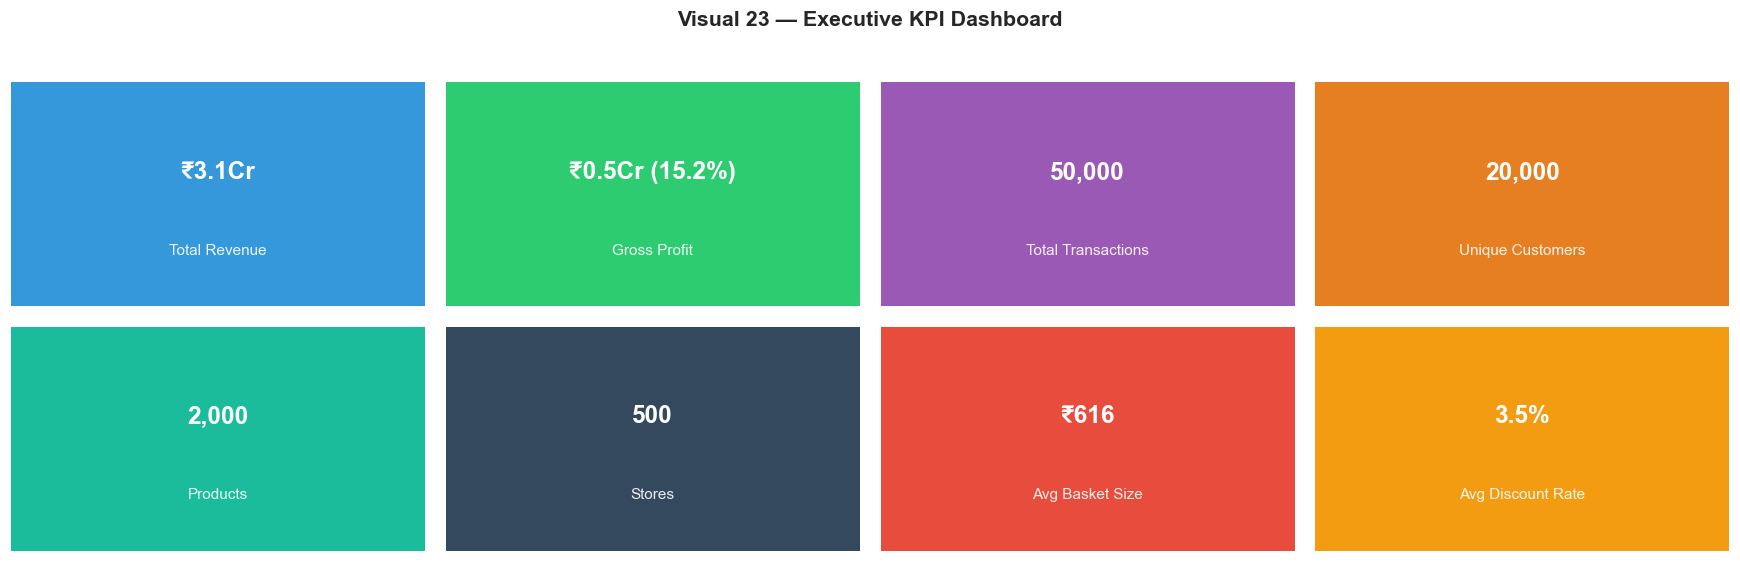


INSIGHT:
  Total Revenue    : ₹3.1 Crores
  Gross Margin     : 15.2% — benchmark for grocery retail is 15-25%
  Avg Basket       : ₹616
  Discount Rate    : 3.5%
  These 8 KPIs are what every retail analyst is asked on Day 1.



In [27]:
total_rev       = fact_sales['sale_amount'].sum()
total_profit    = fact_sales['profit'].sum()
margin_pct      = total_profit / total_rev * 100
total_txns      = fact_sales['transaction_id'].nunique()
total_customers = dim_customer.shape[0]
total_products  = dim_product.shape[0]
total_stores    = dim_store.shape[0]
avg_basket      = fact_sales.groupby('transaction_id')['sale_amount'].sum().mean()
total_disc      = fact_sales['discount_amount'].sum()
disc_rate       = total_disc / total_rev * 100

kpis = [
    ('Total Revenue',      f'₹{total_rev/1e7:.1f}Cr',                     '#3498db'),
    ('Gross Profit',       f'₹{total_profit/1e7:.1f}Cr ({margin_pct:.1f}%)', '#2ecc71'),
    ('Total Transactions', f'{total_txns:,}',                              '#9b59b6'),
    ('Unique Customers',   f'{total_customers:,}',                         '#e67e22'),
    ('Products',           f'{total_products:,}',                          '#1abc9c'),
    ('Stores',             f'{total_stores:,}',                            '#34495e'),
    ('Avg Basket Size',    f'₹{avg_basket:.0f}',                           '#e74c3c'),
    ('Avg Discount Rate',  f'{disc_rate:.1f}%',                            '#f39c12'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
axes = axes.flatten()
for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=16, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=10, color='white', alpha=0.9, transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle('Visual 23 — Executive KPI Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"""
INSIGHT:
  Total Revenue    : ₹{total_rev/1e7:.1f} Crores
  Gross Margin     : {margin_pct:.1f}% — benchmark for grocery retail is 15-25%
  Avg Basket       : ₹{avg_basket:.0f}
  Discount Rate    : {disc_rate:.1f}%
  These 8 KPIs are what every retail analyst is asked on Day 1.
""")

---
**End of ROLAP EDA — 23 Visuals Completed**

| Section | Visuals | Focus |
|---------|---------|-------|
| A | 1–3 | Revenue & Time Trends |
| B | 4–8 | Product & Category |
| C | 9–12 | Store Performance |
| D | 13–16 | Customer Analysis + RFM |
| E | 17–18 | Payment & Discount |
| F | 19 | Supplier |
| G | 20–22 | Aggregate Table Analysis |
| H | 23 | Executive KPI Dashboard |